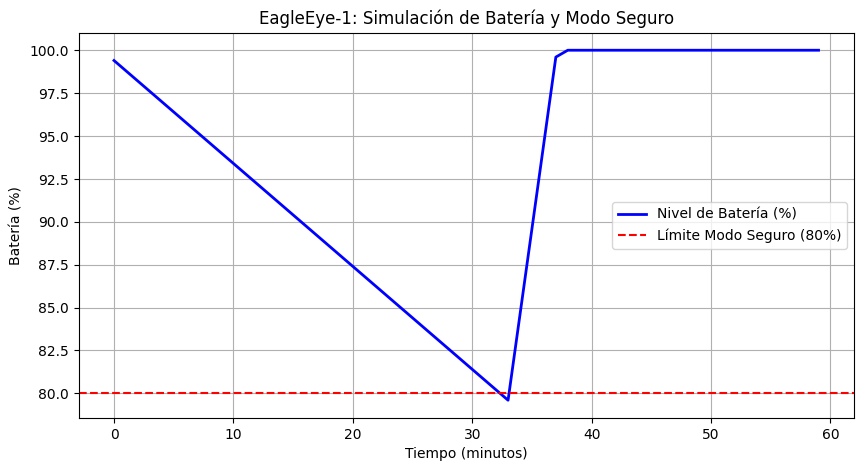

In [1]:
import matplotlib.pyplot as plt

# Parámetros iniciales
bateria_max = 100.0  # Porcentaje
bateria_actual = 100.0
limite_seguro = 80.0

# Consumos (Vatios)
generacion_solar = 40.0
consumo_base = 15.0  # Ordenador central, sensores básicos
consumo_camara = 10.0
consumo_radio = 18.0 # Antena Banda X

tiempo_minutos = range(0, 60)
historial_bateria = []
estado_modo_seguro = []

modo_seguro_activo = False

for t in tiempo_minutos:
    # Si la batería baja del límite, activamos el Modo Seguro
    if bateria_actual < limite_seguro:
        modo_seguro_activo = True
        
    estado_modo_seguro.append(modo_seguro_activo)
    
    # Calcular consumo total según el modo
    if modo_seguro_activo:
        consumo_total = consumo_base # Apagamos cámara y radio
    else:
        consumo_total = consumo_base + consumo_camara + consumo_radio
        
    # Actualizar batería (balance entre lo que entra y lo que sale)
    balance_energia = generacion_solar - consumo_total
    
    # Factor de escala temporal simplificado
    bateria_actual += balance_energia * 0.2 
    
    # La batería no puede superar el 100%
    if bateria_actual > bateria_max:
        bateria_actual = bateria_max
        
    historial_bateria.append(bateria_actual)

# Gráfica de telemetría
plt.figure(figsize=(10, 5))
plt.plot(tiempo_minutos, historial_bateria, label="Nivel de Batería (%)", color="blue", linewidth=2)
plt.axhline(y=limite_seguro, color="red", linestyle="--", label="Límite Modo Seguro (80%)")
plt.title("EagleEye-1: Simulación de Batería y Modo Seguro")
plt.xlabel("Tiempo (minutos)")
plt.ylabel("Batería (%)")
plt.legend()
plt.grid(True)
plt.show()